In [1]:
!pwd

/truejit/evaluation/smartjit


In [5]:
import subprocess


class Workload:
    def __init__(self, name, args):
        self.name = name
        self.args = args

    def __str__(self):
        return f"{self.name}: {self.args}"


class Benchmark:
    def __init__(self, name, binary, dir, workloads):
        self.name = name
        self.binary = binary
        self.dir = dir
        self.workloads = workloads

        cmd = ["wasm-objdump", "-h", binary]
        output = subprocess.run(cmd, check=True, text=True, capture_output=True)
        output = output.stdout
        lines = output.split("\n")
        # get the line that has "Function" in it
        functions = [line for line in lines if "Function" in line][0]
        functions = functions.split(" ")[-1]
        functions = int(functions)

        imports = [line for line in lines if "Import" in line][0]
        imports = imports.split(" ")[-1]
        imports = int(imports)

        self.functions = imports + functions



In [5]:
dir = "/truejit/benchmarks/jetstream/bin/gcc-loops/"
workloads = [
    Workload("default", []),
]

benchmark = Benchmark("gcc-loops", f"{dir}/gcc-loops.wasm", dir, workloads)

In [6]:
dir = "/truejit/benchmarks/ffmpeg"
workloads = [
    Workload("mp4-to-mkv", ['-y', '-opt', f'{dir}/in.mp4', '-c:v', 'libx264', f'{dir}/out.mkv']),
    Workload("mp4-to-wav", ['-y', '-opt', f'{dir}/in.mp4', '-c:a', 'pcm_s16le', f'{dir}/out.wav']),
    Workload("mp4-resize-720p", ['-y', '-opt', f'{dir}/in.mp4', '-vf', 'scale=1280:720', f'{dir}/out_720p.mp4']),
    Workload("jpegs-to-mp4",
             ['-y', '-framerate', '30', '-opt', f'{dir}/img%1d.jpg', '-c:v', 'libx264', f'{dir}/out_video.mp4']),
    Workload("mp4-trim", ['-y', '-opt', f'{dir}/in.mp4', '-t', '0.06', '-c', 'copy', f'{dir}/out_trimmed.mp4']),
    Workload("mp4-flip-vertical", ['-y', '-opt', f'{dir}/in.mp4', '-vf', 'vflip', f'{dir}/out_flip.mp4']),
    Workload("mp4s-concat",
             ['-y', '-f', 'concat', '-safe', '0', '-opt', f'{dir}/list.txt', '-c', 'copy', f'{dir}/out_concat.mp4']),
    Workload("mp4-stream-copy", ['-y', '-opt', f'{dir}/in.mp4', '-c', 'copy', f'{dir}/out_copy.mp4']),
    Workload("mp4-to-pngs", ['-y', '-opt', f'{dir}/in.mp4', '-vf', 'fps=1', f'{dir}/frame_%03d.png']),
    Workload("mp4-speedup-2x", ['-y', '-opt', f'{dir}/in.mp4', '-filter:v', 'setpts=0.5*PTS', f'{dir}/out_2x.mp4']),
    Workload("mp4-slowdown-2x", ['-y', '-opt', f'{dir}/in.mp4', '-filter:v', 'setpts=2.0*PTS', f'{dir}/out_slow.mp4']),
    Workload("mp4-mono-audio", ['-y', '-opt', f'{dir}/in.mp4', '-ac', '1', f'{dir}/out_mono.mp4']),
    Workload("mp4-remove-audio", ['-y', '-opt', f'{dir}/in.mp4', '-an', f'{dir}/out_noaudio.mp4']),
    Workload("mp4-to-flac", ['-y', '-opt', f'{dir}/in.mp4', '-vn', '-c:a', 'flac', f'{dir}/out_audio_only.flac']),
    Workload("mp4-gaussian-blur", ['-y', '-opt', f'{dir}/in.mp4', '-vf', 'gblur=sigma=10', f'{dir}/out_blur.mp4']),
]

ffmpeg = Benchmark("ffmpeg", f"{dir}/ffmpeg.wasm", dir, workloads)

In [21]:
import subprocess
import time
import json

build_type = 'release'
# build_type = 'debug'
vm_bin = [f'/truejit/{build_type}/tools/vm-with-compiler']

benchmark = ffmpeg
cwd = benchmark.dir
app_args = [f'--dir={cwd}'] + [benchmark.binary]
for workload in benchmark.workloads:
    print(f'* {workload.mode}')
    for (scheme_name, vm_options) in [
        ('jit', ['--sync-compilation-strategy=jit']),
        ('oracle', ['--sync-compilation-strategy=jit', '--async-compilation-strategy=oracle']),
        ('dynamic-plan', ['--sync-compilation-strategy=jit', '--async-compilation-strategy=next-dynamic'])]:
        env = {'PROFILE': '/tmp/profiling.json'}
        if scheme_name == 'jit':
            history_file = '/truejit/benchmarks/ffmpeg/ffmpeg.oracle.json'
            env['HISTORY'] = history_file

        cmd = vm_bin + ['--threads=2'] + vm_options + app_args + workload.args
        # print(' '.join(cmd))
        subprocess.run(cmd, check=True, text=True, capture_output=True,
                       cwd=cwd, env=env)
        profile = json.load(open('/tmp/profiling.json'))
        waiting = profile['waiting']
        # e2e = profiling['end-to-end']
        print(f"\t{scheme_name:<15} {waiting / 1000:<5.1f}")

* mp4-to-mkv
	jit             59.4 
	oracle          16.7 
	dynamic-plan    41.2 
* mp4-to-wav
	jit             27.7 
	oracle          13.6 
	dynamic-plan    21.0 
* mp4-resize-720p
	jit             62.2 
	oracle          17.6 
	dynamic-plan    44.4 
* jpegs-to-mp4
	jit             38.0 
	oracle          18.8 
	dynamic-plan    26.3 
* mp4-trim
	jit             26.8 
	oracle          13.1 
	dynamic-plan    20.6 
* mp4-flip-vertical
	jit             60.9 
	oracle          16.9 
	dynamic-plan    42.8 
* mp4s-concat
	jit             27.5 
	oracle          12.6 
	dynamic-plan    21.0 
* mp4-stream-copy
	jit             26.4 
	oracle          13.0 
	dynamic-plan    20.6 
* mp4-to-pngs
	jit             31.8 
	oracle          13.8 
	dynamic-plan    23.6 
* mp4-speedup-2x
	jit             61.0 
	oracle          16.9 
	dynamic-plan    42.7 
* mp4-slowdown-2x
	jit             60.8 
	oracle          16.7 
	dynamic-plan    42.7 
* mp4-mono-audio
	jit             60.9 
	oracle          16.9 
	dynami

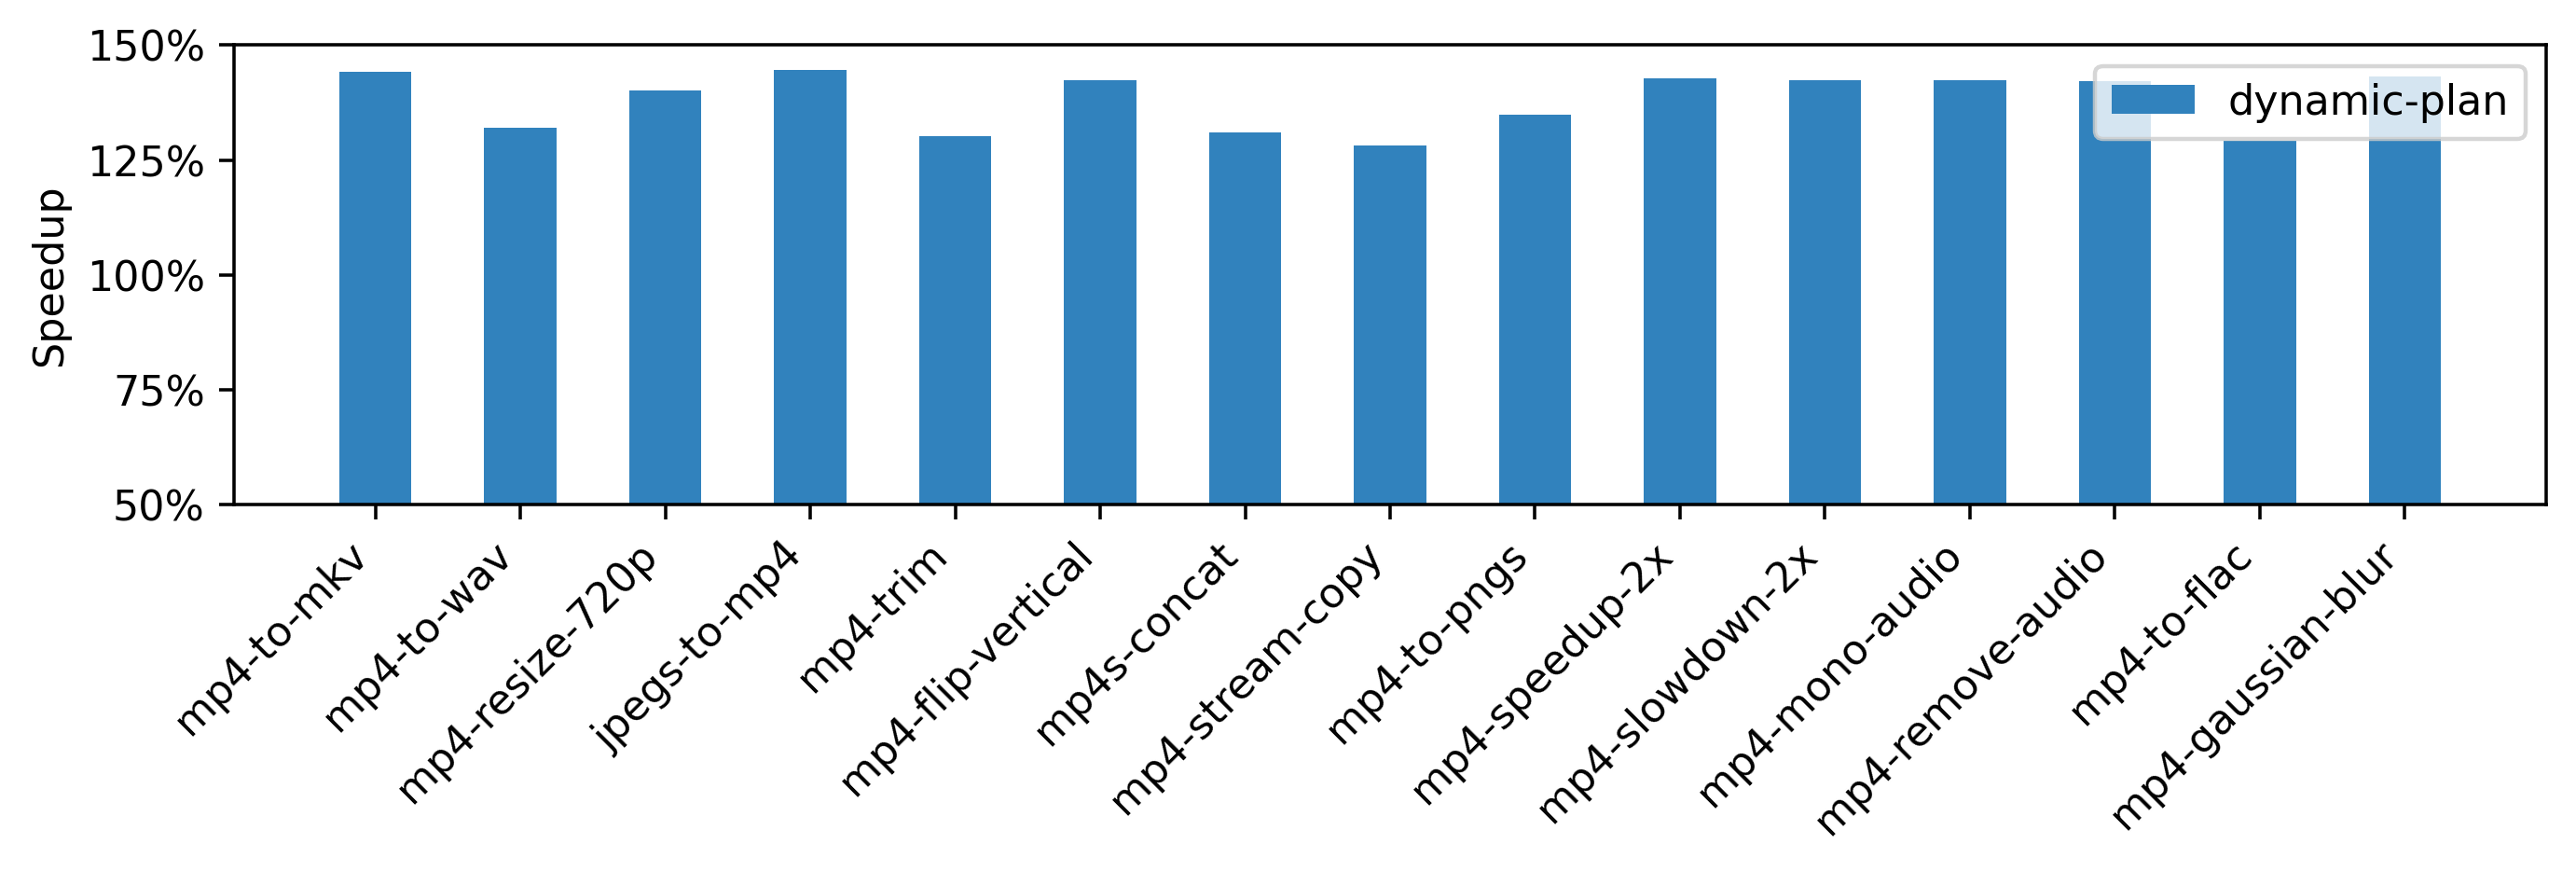

In [79]:
# * mp4-to-mkv
# 	jit             59.4 
# 	oracle          16.7 
# 	dynamic-plan    41.2 
# * mp4-to-wav
# 	jit             27.7 
# 	oracle          13.6 
# 	dynamic-plan    21.0 
# * mp4-resize-720p
# 	jit             62.2 
# 	oracle          17.6 
# 	dynamic-plan    44.4 
# * jpegs-to-mp4
# 	jit             38.0 
# 	oracle          18.8 
# 	dynamic-plan    26.3 
# * mp4-trim
# 	jit             26.8 
# 	oracle          13.1 
# 	dynamic-plan    20.6 
# * mp4-flip-vertical
# 	jit             60.9 
# 	oracle          16.9 
# 	dynamic-plan    42.8 
# * mp4s-concat
# 	jit             27.5 
# 	oracle          12.6 
# 	dynamic-plan    21.0 
# * mp4-stream-copy
# 	jit             26.4 
# 	oracle          13.0 
# 	dynamic-plan    20.6 
# * mp4-to-pngs
# 	jit             31.8 
# 	oracle          13.8 
# 	dynamic-plan    23.6 
# * mp4-speedup-2x
# 	jit             61.0 
# 	oracle          16.9 
# 	dynamic-plan    42.7 
# * mp4-slowdown-2x
# 	jit             60.8 
# 	oracle          16.7 
# 	dynamic-plan    42.7 
# * mp4-mono-audio
# 	jit             60.9 
# 	oracle          16.9 
# 	dynamic-plan    42.8 
# * mp4-remove-audio
# 	jit             57.4 
# 	oracle          15.4 
# 	dynamic-plan    40.4 
# * mp4-to-flac
# 	jit             29.2 
# 	oracle          14.4 
# 	dynamic-plan    22.6 
# * mp4-gaussian-blur
# 	jit             61.1 
# 	oracle          16.4 
# 	dynamic-plan    42.7

# for each workload of above, plot the waiting time for each scheme
import matplotlib.pyplot as plt
import bokeh.palettes

workloads = [
    'mp4-to-mkv',
    'mp4-to-wav',
    'mp4-resize-720p',
    'jpegs-to-mp4',
    'mp4-trim',
    'mp4-flip-vertical',
    'mp4s-concat',
    'mp4-stream-copy',
    'mp4-to-pngs',
    'mp4-speedup-2x',
    'mp4-slowdown-2x',
    'mp4-mono-audio',
    'mp4-remove-audio',
    'mp4-to-flac',
    'mp4-gaussian-blur'
]

schemes = ['jit', 'oracle', 'dynamic-plan']

# use the numbers from top of the cell
waiting_times = {
    'mp4-to-mkv': [59.4, 16.7, 41.2],
    'mp4-to-wav': [27.7, 13.6, 21.0],
    'mp4-resize-720p': [62.2, 17.6, 44.4],
    'jpegs-to-mp4': [38.0, 18.8, 26.3],
    'mp4-trim': [26.8, 13.1, 20.6],
    'mp4-flip-vertical': [60.9, 16.9, 42.8],
    'mp4s-concat': [27.5, 12.6, 21.0],
    'mp4-stream-copy': [26.4, 13.0, 20.6],
    'mp4-to-pngs': [31.8, 13.8, 23.6],
    'mp4-speedup-2x': [61.0, 16.9, 42.7],
    'mp4-slowdown-2x': [60.8, 16.7, 42.7],
    'mp4-mono-audio': [60.9, 16.9, 42.8],
    'mp4-remove-audio': [57.4, 15.4, 40.4],
    'mp4-to-flac': [29.2, 14.4, 22.6],
    'mp4-gaussian-blur': [61.1, 16.4, 42.7]
}

for workload in workloads:
    jit = waiting_times[workload][0]
    waiting_times[workload] = [jit / waiting for waiting in waiting_times[workload]]
for workload in workloads:
    waiting_times[workload] = waiting_times[workload][2:]
schemes = schemes[2:]

colors = bokeh.palettes.Blues3

# plot all in same figure:
# wl#1_jit, wl#1_oracle, wl#1_dynamic-plan, <space>, wl#2_jit, wl#2_oracle, wl#2_dynamic-plan, ...
fig, ax = plt.subplots(figsize=(10, 2), dpi=320)
for i, workload in enumerate(workloads):
    for j, scheme in enumerate(schemes):
        ax.bar(i * len(schemes) + j + 1, waiting_times[workload][j], color=colors[j], label=scheme, width=.5)

# x-axis labels is only the workload names (no scheme names)
ax.set_xticks([i * len(schemes) + 1 for i in range(len(workloads))])
ax.set_xticklabels(workloads, rotation=45, ha='right')

# y is waiting time
ax.set_ylabel('Speedup')
# make y log
# ax.set_yscale('log')

# labels are 50%, 75%, 100%, 125%, 150%
# lim is 50% to 150%
ax.set_ylim(.5, 1.5)
ax.set_yticks([.5, .75, 1, 1.25, 1.5])
ax.set_yticklabels(['50%', '75%', '100%', '125%', '150%'])

# legend; column 3
ax.legend(schemes, loc='upper right', ncol=len(schemes))

plt.show()

In [6]:
import subprocess
from concurrent.futures import ThreadPoolExecutor
import json

subprocess.run(["mkdir", "-p", "/tmp/histories/"], check=True)

# build_type = "debug"
build_type = "release"
vm = f"/truejit/{build_type}/tools/vm-with-compiler"
vm_options = ["--sync-compilation-strategy=jit"]
history_dir = f"/tmp/histories/{benchmark.name}"
pre_open = benchmark.dir
cwd = pre_open

subprocess.run(["rm", "-rf", history_dir], check=True)
subprocess.run(["mkdir", "-p", history_dir], check=True)

with ThreadPoolExecutor() as executor:
    futures = []
    for wl_idx, wl in enumerate(benchmark.workloads):
        name = wl.mode

        args = wl.args[:]
        args += [">", "/dev/null", "2>", "/dev/null"]

        cmd = [vm] + vm_options + [f"--dir={pre_open}"] + [benchmark.binary] + args

        history_file = f"{history_dir}/{wl_idx:02d}.json"
        env = {'HISTORY': history_file}

        futures.append(
            executor.submit(subprocess.run, cmd, check=True, text=True, capture_output=True, env=env, cwd=cwd))

for wl_idx, future in enumerate(futures):
    future.result()

In [5]:
import os

history_dir = f"/tmp/histories/{benchmark.name}"
for file in os.listdir(history_dir):
    if file.endswith('.json'):
        print(file)

03.json
06.json
12.json
14.json
11.json
09.json
08.json
07.json
01.json
04.json
13.json
02.json
00.json
10.json
05.json


In [6]:
import os
import json

histories = []
history_dir = f"/tmp/histories/{benchmark.name}"
for file in os.listdir(history_dir):
    if file.endswith('.json'):
        profile = json.load(open(f'{history_dir}/{file}'))
        histories.append(profile)

In [15]:
import os
import json

dynamic_plan = {}
for history in histories:
    for f_idx in range(len(history) - 1):
        f = history[f_idx]
        next_f = history[f_idx + 1]
        if f not in dynamic_plan:
            dynamic_plan[f] = [next_f]
        else:
            if next_f not in dynamic_plan[f]:
                dynamic_plan[f].append(next_f)

if benchmark.binary.endswith('.wasm'):
    dynamic_plan_path = benchmark.binary.replace('.wasm', '.dynamic-plan.json')
elif benchmark.binary.endswith('.wat'):
    dynamic_plan_path = benchmark.binary.replace('.wat', '.dynamic-plan.json')

with open(dynamic_plan_path, 'w') as f:
    json.dump(dynamic_plan, f)
dynamic_plan

{26: [24],
 24: [30],
 30: [1540],
 1540: [1588],
 1588: [1545],
 1545: [1510],
 1510: [1511],
 1511: [1546],
 1546: [1585],
 1585: [1514],
 1514: [1788],
 1788: [1786],
 1786: [1512],
 1512: [1513],
 1513: [1798],
 1798: [1800],
 1800: [1534],
 1534: [1537],
 1537: [1536],
 1536: [2379],
 2379: [2225],
 2225: [2226],
 2226: [1742],
 1742: [2356],
 2356: [2239],
 2239: [2238],
 2238: [2232],
 2232: [2234],
 2234: [1794],
 1794: [2240],
 2240: [2242],
 2242: [1593],
 1593: [1591],
 1591: [1592],
 1592: [1539],
 1539: [1793],
 1793: [2245],
 2245: [2380],
 2380: [2512],
 2512: [2381],
 2381: [2257],
 2257: [2258],
 2258: [1879],
 1879: [4309],
 4309: [2350],
 2350: [27186],
 27186: [27183],
 27183: [1918],
 1918: [8690],
 8690: [1762],
 1762: [1747],
 1747: [1748],
 1748: [1724],
 1724: [1734],
 1734: [1749],
 1749: [1805],
 1805: [1784],
 1784: [1763],
 1763: [27049],
 27049: [1743],
 1743: [1572],
 1572: [1542],
 1542: [1796],
 1796: [1795],
 1795: [27187],
 27187: [27188],
 27188: [27

In [7]:
import numpy as np

# don't use scientific notation
np.set_printoptions(suppress=True)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

torch.cuda.is_available()

False

In [4]:
# open json file /tmp/history.txt as a list
import json

json_file = '/tmp/history.txt'
with open(json_file, 'r') as f:
    history = json.load(f)
    histories = [history]
histories

[[14,
  13,
  142,
  117,
  116,
  61,
  367,
  363,
  331,
  681,
  332,
  144,
  156,
  362,
  333,
  386,
  334,
  335,
  336,
  405,
  599,
  597,
  678,
  337,
  338,
  339,
  340,
  341,
  451,
  342,
  452,
  343,
  344,
  345,
  346,
  347,
  348,
  349,
  350,
  351,
  352,
  353,
  354,
  355,
  356,
  357,
  358,
  359,
  360,
  361,
  368,
  121,
  370,
  401,
  402,
  369,
  57,
  90,
  132,
  410,
  603,
  608,
  576,
  411,
  588,
  560,
  562,
  550,
  551,
  555,
  561,
  32,
  15,
  558,
  565,
  546,
  33,
  16,
  547,
  553,
  554,
  17,
  18,
  679,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  34,
  83,
  52,
  393,
  37,
  129,
  634,
  625,
  84,
  85,
  210,
  211,
  212,
  655,
  650,
  651,
  633,
  652,
  656,
  213,
  461,
  394,
  86,
  216,
  217,
  644,
  615,
  567,
  619,
  618,
  572,
  589,
  587,
  115,
  119,
  118,
  78,
  128,
  400,
  611,
  107,
  112,
  139,
  409,
  609,
  113,
  624,
  640]]

In [7]:
import subprocess

cmd = ["wasm-objdump", "-h", '/truejit/benchmarks/jetstream/bin/gcc-loops/gcc-loops.wasm']
output = subprocess.run(cmd, check=True, text=True, capture_output=True)
output = output.stdout
lines = output.split("\n")
# get the line that has "Function" in it
functions = [line for line in lines if "Function" in line][0]
functions = functions.split(" ")[-1]
functions = int(functions)
functions

686

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import json

# use gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")
# if cude is available, clear the cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

window_size = 1


# Custom dataset class
class HistoryDataset(Dataset):
    def __init__(self, histories, window_size):
        self.data = []
        self.labels = []
        for dataset in histories:
            if len(dataset) == 0:
                continue

            self.data += [[0] * (window_size - i - 1) + dataset[:i + 1] for i in range(window_size - 1)]
            self.labels += dataset[1:window_size]

            self.data += [dataset[i - window_size:i] for i in range(window_size, len(dataset))]
            self.labels += dataset[window_size:]

        self.data = torch.tensor(self.data, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


# Create dataset and dataloader
dataset = HistoryDataset(histories, window_size)
dataloader = DataLoader(dataset, batch_size=8192, shuffle=True)


# The LSTM model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.clamp(0, self.embedding.num_embeddings - 1)
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        output = self.fc(lstm_out[:, -1, :])
        return output


# Parameters
embed_size = 32
hidden_size = 64

# Instantiate the model, loss function, and optimizer
model = LSTMModel(functions, embed_size, hidden_size, functions).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# Training loop
epochs = 1000
for epoch in range(epochs):
    model.train()
    for batch_data, batch_labels in dataloader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        output = model(batch_data)
        loss = criterion(output, batch_labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

# move the model to cpu
model = model.cpu()

Using cpu
Epoch 10/1000, Loss: 0.00037221756065264344
Epoch 20/1000, Loss: 2.7429503461462446e-05
Epoch 30/1000, Loss: 1.0238192771794274e-05
Epoch 40/1000, Loss: 5.183851499168668e-06
Epoch 50/1000, Loss: 3.686340505737462e-06
Epoch 60/1000, Loss: 2.973584741994273e-06
Epoch 70/1000, Loss: 2.554704224166926e-06
Epoch 80/1000, Loss: 2.2715862542099785e-06
Epoch 90/1000, Loss: 2.066283741442021e-06
Epoch 100/1000, Loss: 1.9048566173296422e-06
Epoch 110/1000, Loss: 1.7699195495879394e-06
Epoch 120/1000, Loss: 1.6515391507709865e-06
Epoch 130/1000, Loss: 1.5513710422965232e-06
Epoch 140/1000, Loss: 1.4685875839859364e-06
Epoch 150/1000, Loss: 1.3874596334062517e-06
Epoch 160/1000, Loss: 1.3212326166467392e-06
Epoch 170/1000, Loss: 1.2558334674395155e-06
Epoch 180/1000, Loss: 1.1970571449637646e-06
Epoch 190/1000, Loss: 1.1440754406066844e-06
Epoch 200/1000, Loss: 1.0952330740110483e-06
Epoch 210/1000, Loss: 1.049701950250892e-06
Epoch 220/1000, Loss: 1.0099656719830818e-06
Epoch 230/1000,

In [12]:
# save pt model to /tmp/model.pt
model_path = '/tmp/model.pt'
torch.jit.save(torch.jit.script(model.eval()), model_path)

In [10]:
!mkdir -p /tmp/models

In [11]:
# model_path is the dir/name.pt
# /truejit/benchmarks/jetstream/bin/gcc-loops/gcc-loops.wasm -> /truejit/benchmarks/jetstream/bin/gcc-loops/gcc-loops.pt
# replace .wasm or .wat with .pt
if benchmark.binary.endswith('.wasm'):
    model_path = benchmark.binary.replace('.wasm', '.pt')
elif benchmark.binary.endswith('.wat'):
    model_path = benchmark.binary.replace('.wat', '.pt')

In [12]:
# Save the model
if os.path.exists(model_path):
    os.remove(model_path)
torch.jit.save(torch.jit.script(model.eval()), model_path)

In [24]:
# Load the model
model = torch.jit.load(model_path)

# Predict
model.eval()
with torch.no_grad():
    for item in nexts.items():
        x = torch.tensor([[item[0]]])
        y_pred = model(x)
        tops = torch.softmax(y_pred, dim=1).topk(len(item[1]))
        if len(item[1]) == 1:
            assert tops.indices.numpy()[0] == list(item[1])[0]
            # assert probability of the top prediction is more than .8
            assert tops.values.numpy()[0] > .8
        if len(item[1]) > 1:
            print(tops.values.numpy())
            print(tops.indices.numpy())
            print()

In [15]:
input = torch.tensor([[24]])
output = model(input)
tops = torch.softmax(output, dim=1).topk(3)
tops

torch.return_types.topk(
values=tensor([[1.0000e+00, 1.4527e-06, 2.4616e-07]], grad_fn=<TopkBackward0>),
indices=tensor([[   30,  4452, 12679]]))

In [14]:
for history in histories:
    print(history[:20])

[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1513, 1798, 1800, 1534, 1537, 1536]
[26, 24, 30, 1540, 1588, 1545, 1510, 1511, 1546, 1585, 1514, 1788, 1786, 1512, 1

In [3]:
# train model per benchmark using their single history
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import json

json_file = '/tmp/hist.json'
with open(json_file, 'r') as f:
    history = json.load(f)
histories = [history]

# use gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")
# if cude is available, clear the cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

window_size = 10


class HistoryDataset(Dataset):
    def __init__(self, histories, window_size):
        self.data = []
        self.labels = []
        for dataset in histories:
            if len(dataset) == 0:
                continue

            self.data += [[0] * (window_size - i - 1) + dataset[:i + 1] for i in range(window_size - 1)]
            self.labels += dataset[1:window_size]

            self.data += [dataset[i - window_size:i] for i in range(window_size, len(dataset))]
            self.labels += dataset[window_size:]

        self.data = torch.tensor(self.data, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


# Create dataset and dataloader
dataset = HistoryDataset(histories, window_size)
dataloader = DataLoader(dataset, batch_size=8192, shuffle=True)


# The LSTM model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.clamp(0, self.embedding.num_embeddings - 1)
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        output = self.fc(lstm_out[:, -1, :])
        return output


# Parameters
embed_size = 32
hidden_size = 64

# Instantiate the model, loss function, and optimizer
model = LSTMModel(benchmark.functions, embed_size, hidden_size, benchmark.functions).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# Training loop
epochs = 1000
for epoch in range(epochs):
    model.train()
    for batch_data, batch_labels in dataloader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        output = model(batch_data)
        loss = criterion(output, batch_labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

# move the model to cpu
model = model.cpu()

# Epoch 400/500, Loss: 0.1380666047334671
# Epoch 410/500, Loss: 0.13012239336967468
# Epoch 420/500, Loss: 0.13822652399539948
# Epoch 430/500, Loss: 0.12944869697093964
# Epoch 440/500, Loss: 0.1419658362865448
# Epoch 450/500, Loss: 0.1243339478969574
# Epoch 460/500, Loss: 0.13929176330566406
# Epoch 470/500, Loss: 0.13426218926906586
# Epoch 480/500, Loss: 0.1260155588388443
# Epoch 490/500, Loss: 0.1367834359407425
# Epoch 500/500, Loss: 0.13519123196601868

Using cuda


NameError: name 'benchmark' is not defined